<a href="https://colab.research.google.com/github/eshanth23/cs666student/blob/main/CS666_Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

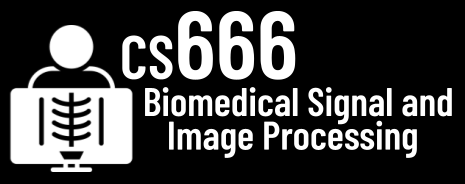
#Assignment 6

In [ ]:
# NAME:Eshanth Kumar Lal Das

In [1]:
# In this assignment, we will visualize and explore a CT scan!

In [2]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [3]:
# we are using pydicom, so lets install it!
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 45.4 MB/s eta 0:00:00


**Task 1**: Download and visualize data with SliceDrop! [20 Points]

In [ ]:
# Use wget to download https://cs666.org/data/ct.zip!
# This is a CT scan of an arm in DICOM format.

In [10]:
# TODO: YOUR CODE
!wget https://cs666.org/data/ct.zip

--2026-04-29 15:34:58--  https://cs666.org/data/ct.zip
Resolving cs666.org (cs666.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to cs666.org (cs666.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5847706 (5.6M) [application/x-zip-compressed]
Saving to: ‘ct.zip.2’

ct.zip.2            100%[===================>]   5.58M  --.-KB/s    in 0.04s   

2026-04-29 15:34:58 (140 MB/s) - ‘ct.zip.2’ saved [5847706/5847706]



In [ ]:
# Then use the following snippet to extract the data.

In [14]:
import os
files = sorted(os.listdir('.'))
for f in files:
    print(f)

.config
__MACOSX
ct
ct.zip
ct.zip.1
ct.zip.2
ct_data
ct_dicom_files.zip
sample_data


In [ ]:
# 1) Let's explore the data using the Files panel on the left.
# TODO: How many slices are there?

In [15]:
# TODO: YOUR_ANSWER

import os
dicom_files = [f for f in os.listdir('ct') if not f.startswith('.')]
print("Number of slices:", len(dicom_files))
print("Files:", sorted(dicom_files))

Number of slices: 220
Files: ['IM-0001-0001.dcm', 'IM-0001-0002.dcm', 'IM-0001-0003.dcm', 'IM-0001-0004.dcm', 'IM-0001-0005.dcm', 'IM-0001-0006.dcm', 'IM-0001-0007.dcm', 'IM-0001-0008.dcm', 'IM-0001-0009.dcm', 'IM-0001-0010.dcm', 'IM-0001-0011.dcm', 'IM-0001-0012.dcm', 'IM-0001-0013.dcm', 'IM-0001-0014.dcm', 'IM-0001-0015.dcm', 'IM-0001-0016.dcm', 'IM-0001-0017.dcm', 'IM-0001-0018.dcm', 'IM-0001-0019.dcm', 'IM-0001-0020.dcm', 'IM-0001-0021.dcm', 'IM-0001-0022.dcm', 'IM-0001-0023.dcm', 'IM-0001-0024.dcm', 'IM-0001-0025.dcm', 'IM-0001-0026.dcm', 'IM-0001-0027.dcm', 'IM-0001-0028.dcm', 'IM-0001-0029.dcm', 'IM-0001-0030.dcm', 'IM-0001-0031.dcm', 'IM-0001-0032.dcm', 'IM-0001-0033.dcm', 'IM-0001-0034.dcm', 'IM-0001-0035.dcm', 'IM-0001-0036.dcm', 'IM-0001-0037.dcm', 'IM-0001-0038.dcm', 'IM-0001-0039.dcm', 'IM-0001-0040.dcm', 'IM-0001-0041.dcm', 'IM-0001-0042.dcm', 'IM-0001-0043.dcm', 'IM-0001-0044.dcm', 'IM-0001-0045.dcm', 'IM-0001-0046.dcm', 'IM-0001-0047.dcm', 'IM-0001-0048.dcm', 'IM-0001-0

In [ ]:
# 2) Let's visualize the data with SliceDrop!
# Go to https://slicedrop.com and drag'n'drop all .dcm files into the browser.
# Please use the 2D sliders to show axial, sagittal, and coronal slices in 3D.

In [ ]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click. This should not be volume
# rendering but show the 3 cross sections.

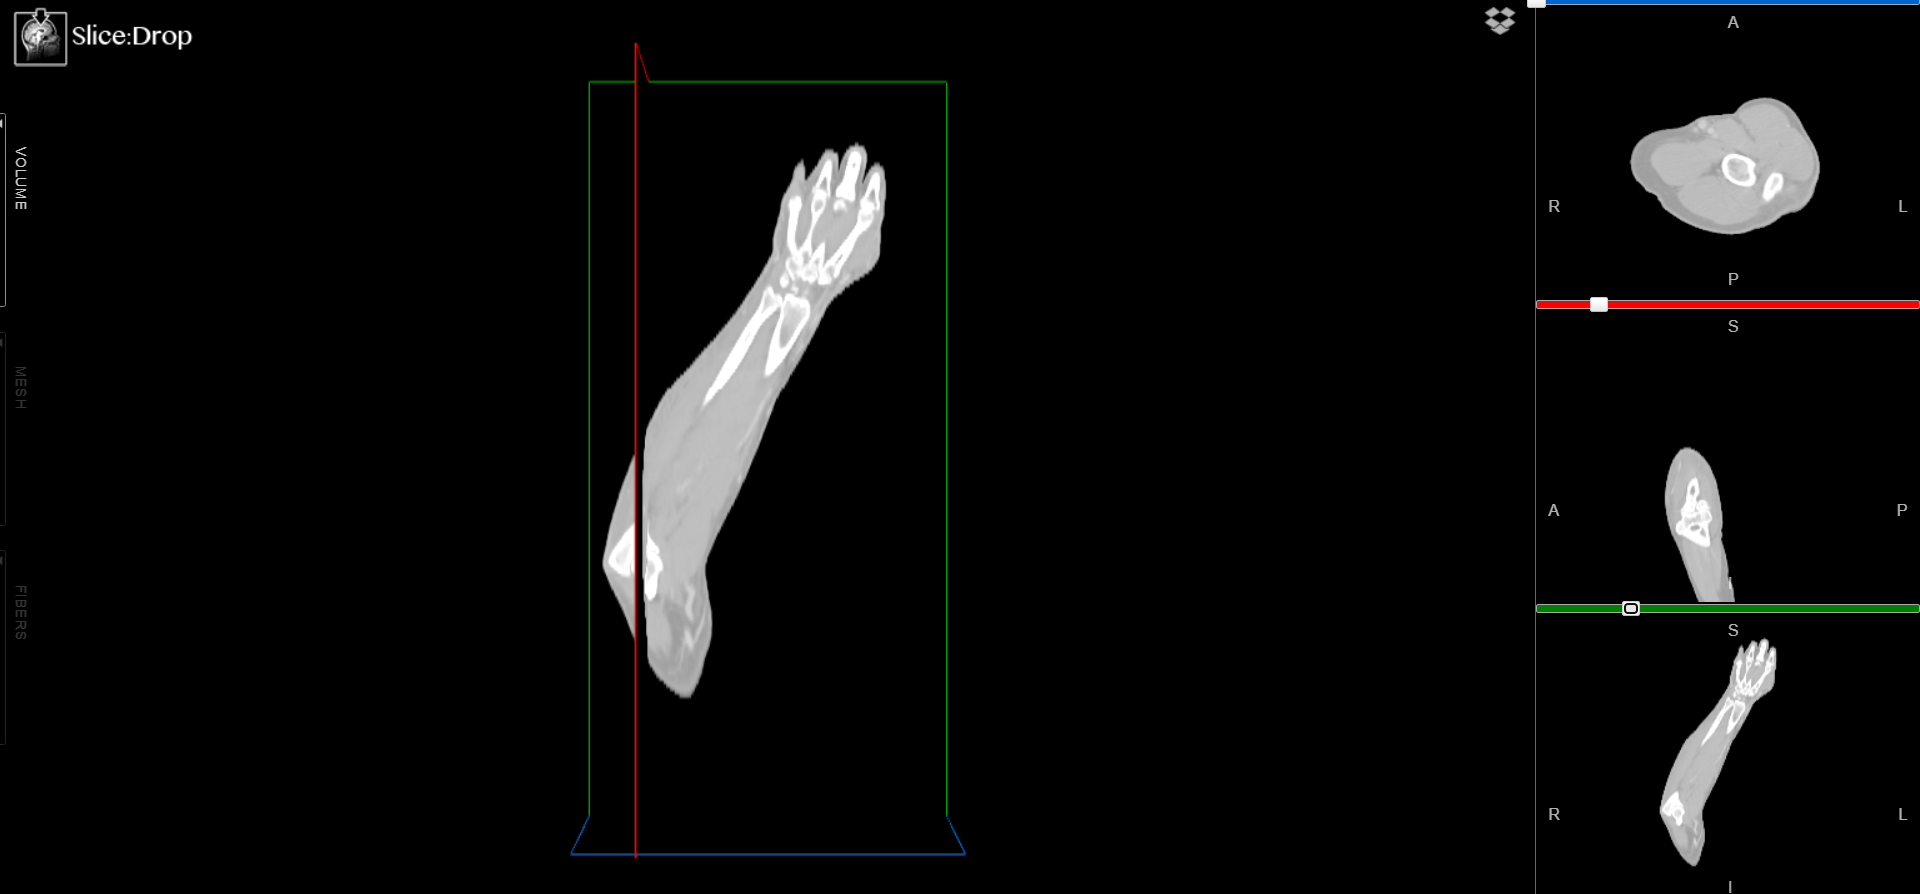

In [ ]:
# 3) Let's visualize only the bones! Please use the thresholding
# based on a window suitable for bones and show a 3D volume rendering.

In [ ]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click.

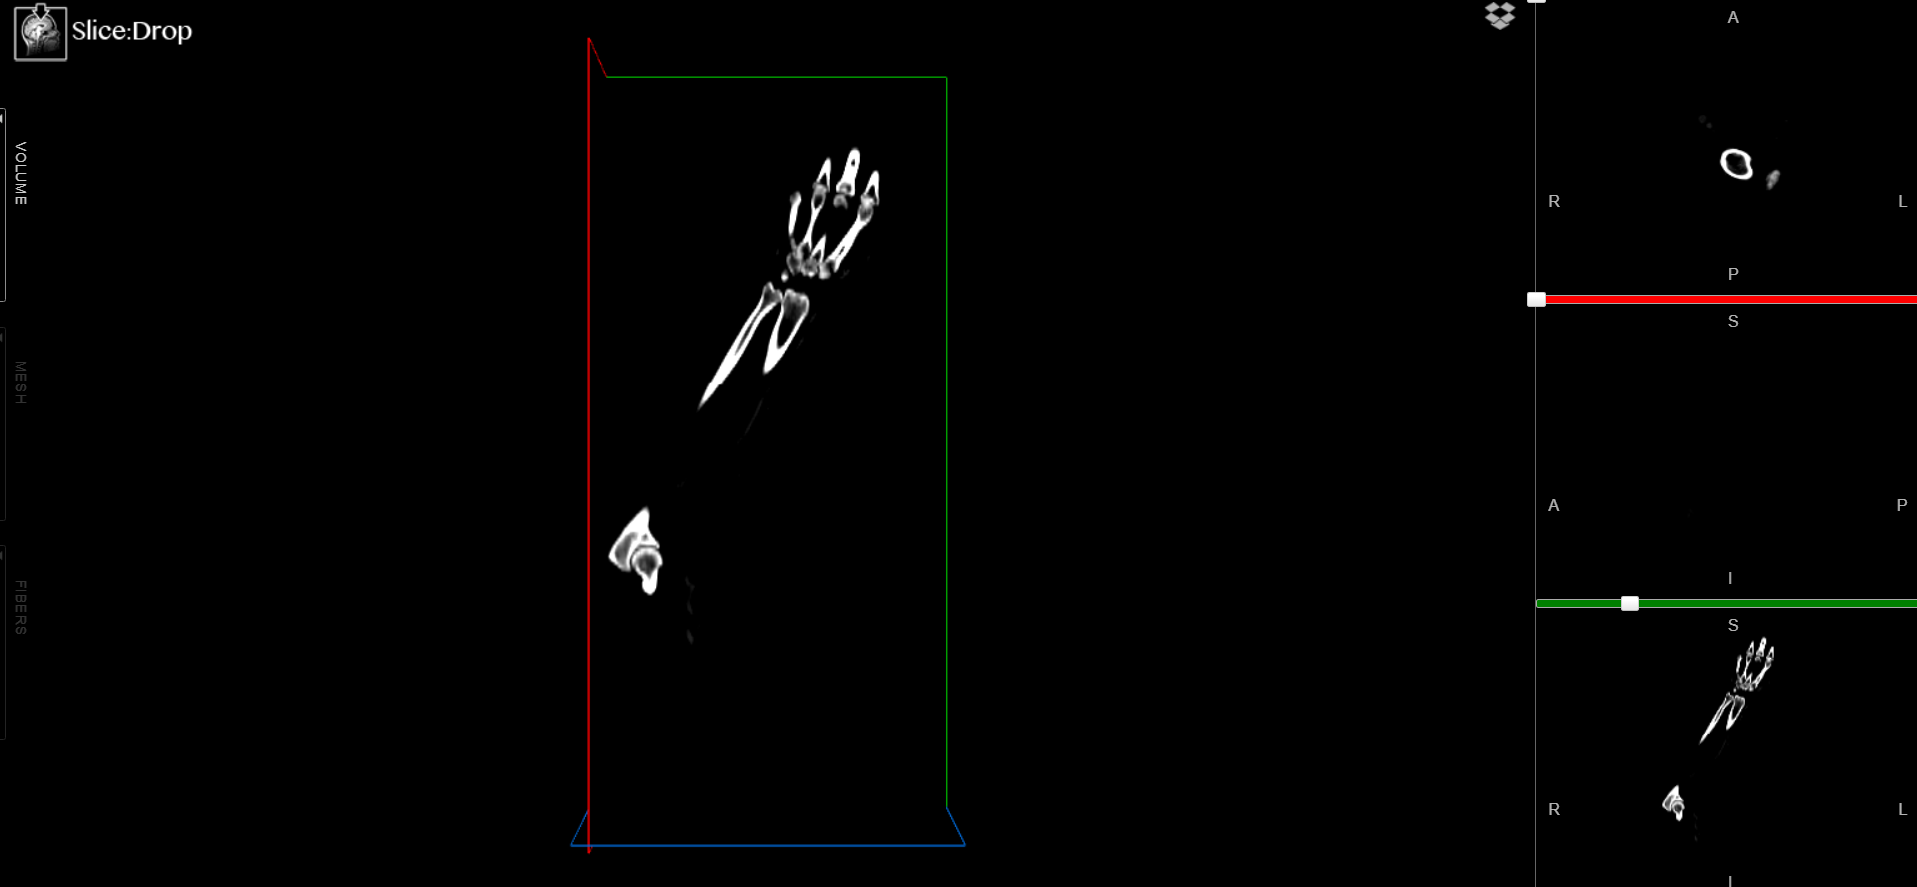

**Task 2**: Load the data using pydicom as a 3D volume and then reslice it! [35 Points]

In [16]:
# 1) Now loop through all the DICOM files and store them in a 3D numpy array.
# Hint: You can either store them in a list first or read the dimensions of a
# single image slice to properly create the 3D numpy array.
# Hint 2: os.listdir(DIR) gives a list of filenames in a directory.
# Hint 2b: This list is not sorted - make sure you sort it.
# Hint 3: The dcmread function loads a single DICOM file.
# Hint 4: You can then use .pixel_array to access the image data.

In [17]:
from pydicom import dcmread

In [19]:
# TODO: YOUR CODE FOR LOADING THE VOLUME AS A 3D NUMPY ARRAY

from pydicom import dcmread
import os
import numpy as np

DIR = 'ct/'

# Get sorted list of DICOM files
files = sorted([f for f in os.listdir(DIR) if not f.startswith('.')])

# Read first slice to get dimensions
first_slice = dcmread(os.path.join(DIR, files[0]))
rows, cols = first_slice.pixel_array.shape
num_slices = len(files)

# Create empty 3D array
volume = np.zeros((num_slices, rows, cols), dtype=np.float32)

# Loop through all DICOM files and store in 3D array
for i, filename in enumerate(files):
    ds = dcmread(os.path.join(DIR, filename))
    volume[i] = ds.pixel_array

print("Volume shape:", volume.shape)
print("Min value:", volume.min())
print("Max value:", volume.max())

Volume shape: (220, 454, 512)
Min value: 0.0
Max value: 2894.0


In [ ]:
# 2) Now create and show axial, sagittal, and coronal slices from the 3D volume.
# Hint: Please use imshow(XX, cmap='gray') to show the image.

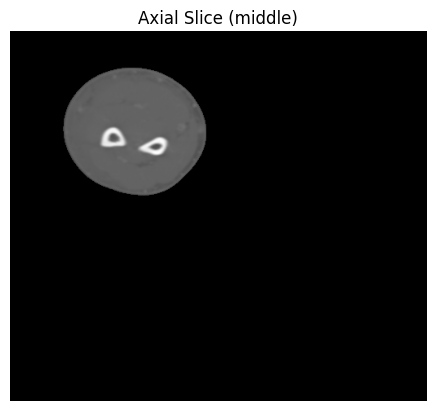

In [20]:
# TODO: YOUR CODE FOR AXIAL
import matplotlib.pyplot as plt

axial_slice = volume[110]  # middle slice
plt.imshow(axial_slice, cmap='gray')
plt.title('Axial Slice (middle)')
plt.axis('off')
plt.show()

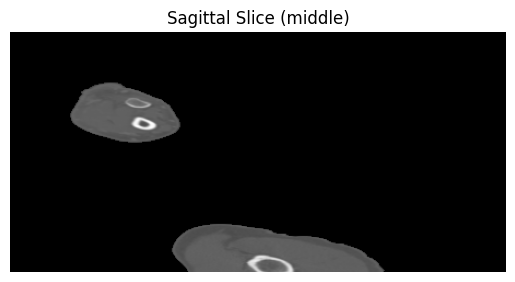

In [21]:
# TODO: YOUR CODE FOR SAGITTAL
sagittal_slice = volume[:, :, 256]  # middle column
plt.imshow(sagittal_slice, cmap='gray')
plt.title('Sagittal Slice (middle)')
plt.axis('off')
plt.show()

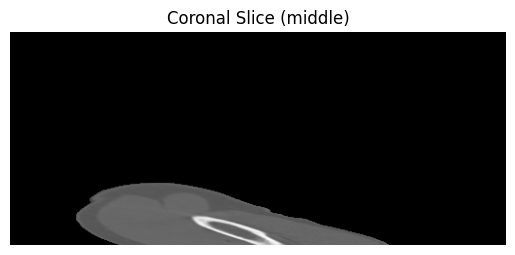

In [22]:
# TODO: YOUR CODE FOR CORONAL
coronal_slice = volume[:, 227, :]  # middle row
plt.imshow(coronal_slice, cmap='gray')
plt.title('Coronal Slice (middle)')
plt.axis('off')
plt.show()

**Task 3**: Use the Window/Level-technique to visualize the data! [45 Points]

In [ ]:
# We will now enhance the visualization from above by performing
# Window/Level adjustment.
# Here is one way of doing that:
#   vmin = level - window/2
#   vmax = level + window/2
#   plt.imshow(hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
#   plt.show()

In [ ]:
# 1) Please load the Window/Level values from the DICOM file,
# print these values, and then visualize one slice with window/level adjustment.
# Hint: The DICOM header has the following tags.
#   (0028, 1050) Window Center
#   (0028, 1051) Window Width
# Hint 2: You can use slice[key].value to access DICOM tag values.
# Hint 3: (0028, 1052) Rescale Intercept might be important.

Window Width: 410
Window Center (Level): 30
Rescale Intercept: -1024
vmin: -175.0
vmax: 235.0


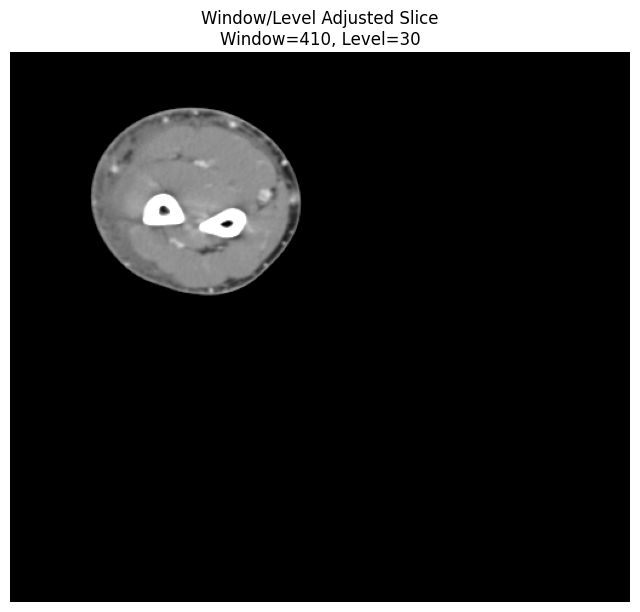

In [24]:
# TODO: YOUR CODE

import pydicom

# Read first DICOM file to get header info
ds = dcmread(os.path.join(DIR, files[110]))  # middle slice

# Load Window/Level values from DICOM header
window = ds[0x0028, 0x1051].value  # Window Width
level = ds[0x0028, 0x1050].value   # Window Center
rescale = ds[0x0028, 0x1052].value # Rescale Intercept

# Handle cases where values might be lists
if isinstance(window, pydicom.multival.MultiValue):
    window = float(window[0])
if isinstance(level, pydicom.multival.MultiValue):
    level = float(level[0])

print("Window Width:", window)
print("Window Center (Level):", level)
print("Rescale Intercept:", rescale)

# Calculate vmin and vmax
vmin = level - window/2
vmax = level + window/2

print("vmin:", vmin)
print("vmax:", vmax)

# Visualize with window/level adjustment
slice_data = volume[110]  # middle slice

plt.figure(figsize=(8, 8))
plt.imshow(slice_data + rescale, cmap='gray', vmin=vmin, vmax=vmax)
plt.title(f'Window/Level Adjusted Slice\nWindow={window}, Level={level}')
plt.axis('off')
plt.show()

In [ ]:
# 2) Play around with different Window/Level values that enhance
# the visualization.

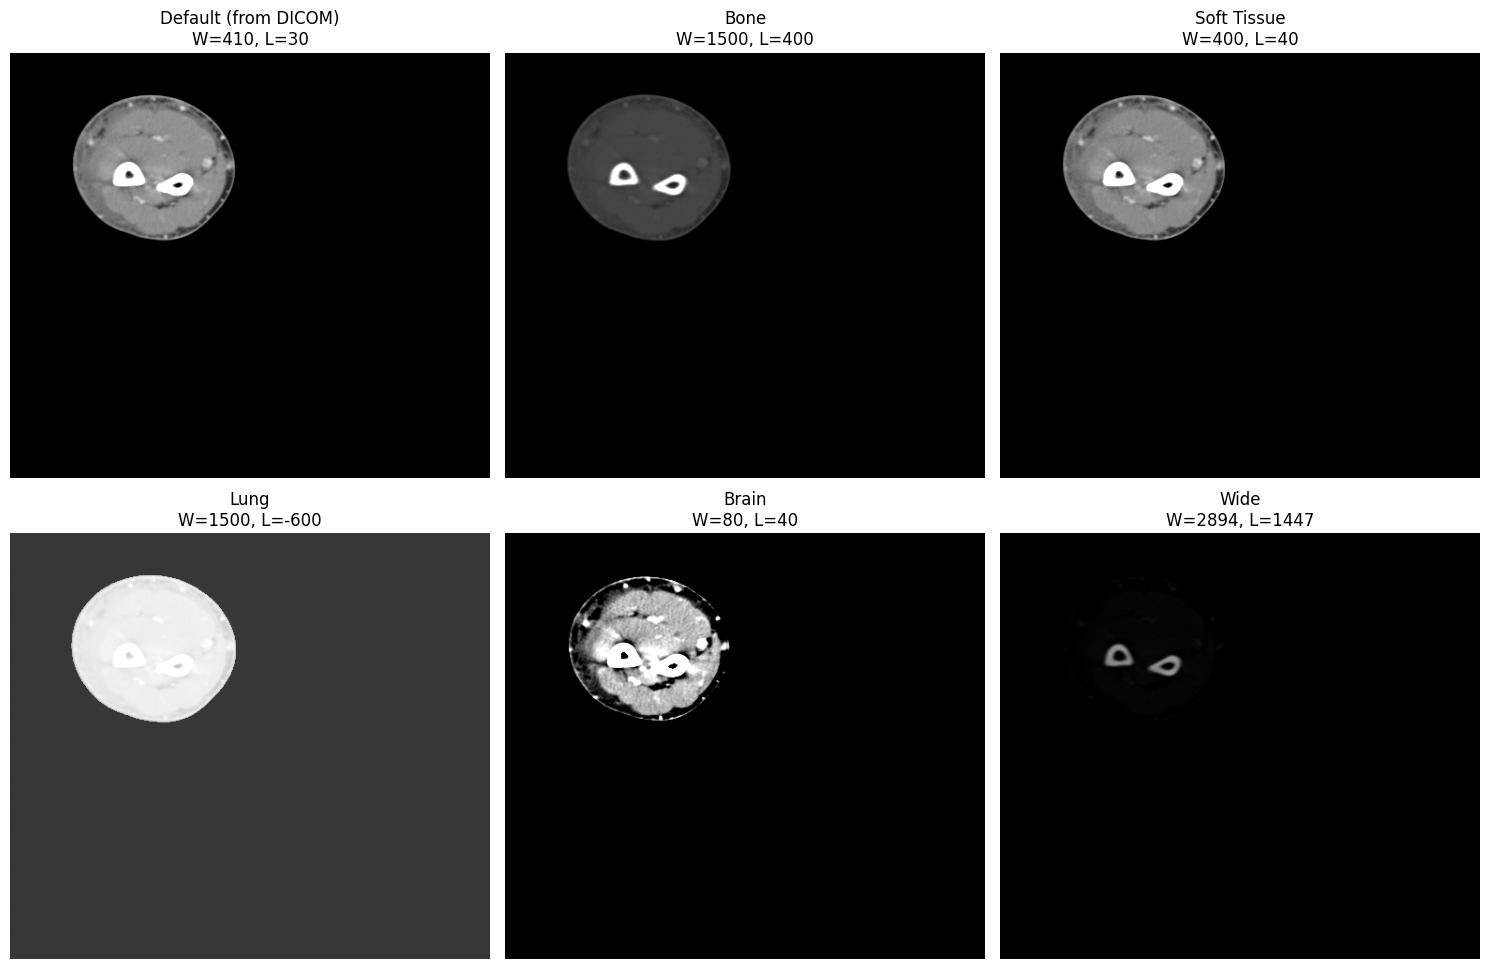


Different Window/Level presets reveal different structures:
- Default: uses the window/level stored in the DICOM file
- Bone (W=1500, L=400): highlights dense bone structures clearly
- Soft Tissue (W=400, L=40): shows muscles and organs with good contrast
- Lung (W=1500, L=-600): optimized for air-filled lung structures
- Brain (W=80, L=40): narrow window for subtle brain tissue differences
- Wide (W=2894, L=1447): shows full range of all values in the scan

The Bone preset works best for this arm CT scan as it clearly shows
the cortical bone, bone marrow, and surrounding soft tissue.



In [26]:
# TODO: YOUR CODE

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

slice_data = volume[110] + rescale

# Different window/level presets
presets = [
    {"name": "Default (from DICOM)", "window": window, "level": level},
    {"name": "Bone", "window": 1500, "level": 400},
    {"name": "Soft Tissue", "window": 400, "level": 40},
    {"name": "Lung", "window": 1500, "level": -600},
    {"name": "Brain", "window": 80, "level": 40},
    {"name": "Wide", "window": 2894, "level": 1447},
]

for ax, preset in zip(axes.flat, presets):
    vmin = preset["level"] - preset["window"] / 2
    vmax = preset["level"] + preset["window"] / 2
    ax.imshow(slice_data, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(f'{preset["name"]}\nW={preset["window"]}, L={preset["level"]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("""
Different Window/Level presets reveal different structures:
- Default: uses the window/level stored in the DICOM file
- Bone (W=1500, L=400): highlights dense bone structures clearly
- Soft Tissue (W=400, L=40): shows muscles and organs with good contrast
- Lung (W=1500, L=-600): optimized for air-filled lung structures
- Brain (W=80, L=40): narrow window for subtle brain tissue differences
- Wide (W=2894, L=1447): shows full range of all values in the scan

The Bone preset works best for this arm CT scan as it clearly shows
the cortical bone, bone marrow, and surrounding soft tissue.
""")

In [ ]:
# Which values make sense and why?

In [ ]:
# TODO: YOUR ANSWER

In [27]:
print("""
The Window/Level values that make the most sense for this arm CT scan are:

1. Bone Window (W=1500, L=400):
   - Best for this dataset since it is a CT scan of an arm
   - Clearly shows cortical bone (bright white) and bone marrow
   - The wide window captures the full range of bone densities
   - Helps visualize fractures or bone abnormalities

2. Soft Tissue Window (W=400, L=40):
   - Good for visualizing muscles, tendons, and fat around the bones
   - Narrow window provides better contrast for soft tissue structures
   - Useful for identifying soft tissue injuries or abnormalities

3. Default DICOM Window:
   - Provides a reasonable general view of the arm
   - Radiologists set these values when the scan was acquired
   - Good starting point for visualization

The Lung and Brain presets do not make sense for this dataset because:
- Lung window is optimized for air-filled structures which are not
  present in an arm CT scan
- Brain window is too narrow and misses most of the bone detail
  which is the primary structure of interest in this arm scan
""")


The Window/Level values that make the most sense for this arm CT scan are:

1. Bone Window (W=1500, L=400):
   - Best for this dataset since it is a CT scan of an arm
   - Clearly shows cortical bone (bright white) and bone marrow
   - The wide window captures the full range of bone densities
   - Helps visualize fractures or bone abnormalities

2. Soft Tissue Window (W=400, L=40):
   - Good for visualizing muscles, tendons, and fat around the bones
   - Narrow window provides better contrast for soft tissue structures
   - Useful for identifying soft tissue injuries or abnormalities

3. Default DICOM Window:
   - Provides a reasonable general view of the arm
   - Radiologists set these values when the scan was acquired
   - Good starting point for visualization

The Lung and Brain presets do not make sense for this dataset because:
- Lung window is optimized for air-filled structures which are not 
  present in an arm CT scan
- Brain window is too narrow and misses most of the bone d

**Bonus**: Create segmentations (label maps) for the volume using thresholding HU! [33 Points]

In [ ]:
# Similar to Window/Level adjustment for visualization, we can threshold
# the volume to highlight the following components using the Hounsfield Units:
# 1) Fat
# 2) Soft Tissue
# 3) Bones
#
# Please create 3 segmentation masks for these structures.
# Then, please visualize each 3 slices per structure to showcase the segmentation.
# Hint: As a reminder, the following code allows thresholding of a numpy array.
#   new_mask = imagevolume.copy()
#   new_mask[new_mask < XXX] = 0
# Hint2: You might need to cast new_mask to int16 not uint16.

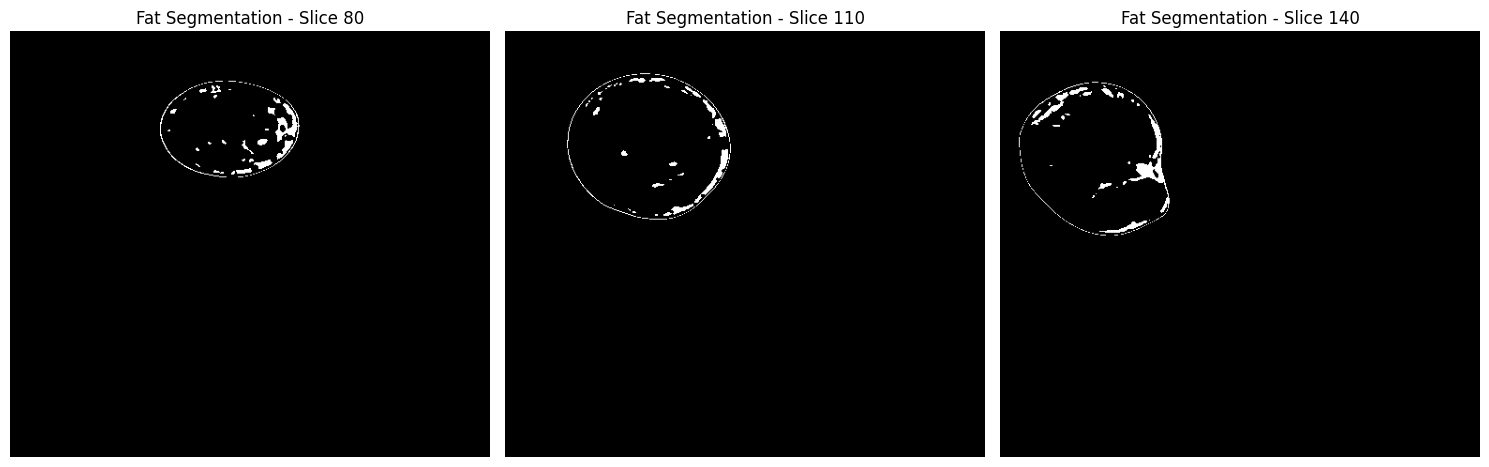

In [28]:
# TODO: YOUR CODE TO SEGMENT FAT
# Fat HU range: -190 to -30
volume_hu = volume.astype(np.int16) + int(rescale)

fat_mask = volume_hu.copy()
fat_mask[fat_mask < -190] = 0
fat_mask[fat_mask > -30] = 0
fat_mask[fat_mask != 0] = 1

# Show 3 slices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
slices = [80, 110, 140]
for ax, s in zip(axes, slices):
    ax.imshow(fat_mask[s], cmap='gray')
    ax.set_title(f'Fat Segmentation - Slice {s}')
    ax.axis('off')
plt.tight_layout()
plt.show()

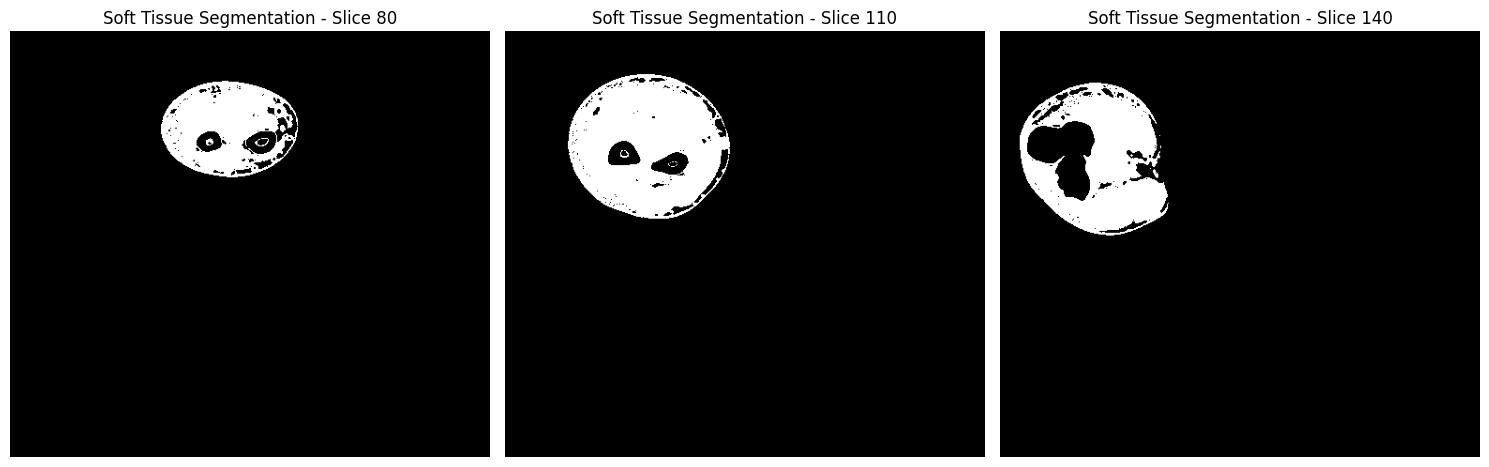

In [29]:
# TODO: YOUR CODE TO SEGMENT SOFT TISSUE
# Soft Tissue HU range: -30 to 150
soft_mask = volume_hu.copy()
soft_mask[soft_mask < -30] = 0
soft_mask[soft_mask > 150] = 0
soft_mask[soft_mask != 0] = 1

# Show 3 slices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
slices = [80, 110, 140]
for ax, s in zip(axes, slices):
    ax.imshow(soft_mask[s], cmap='gray')
    ax.set_title(f'Soft Tissue Segmentation - Slice {s}')
    ax.axis('off')
plt.tight_layout()
plt.show()

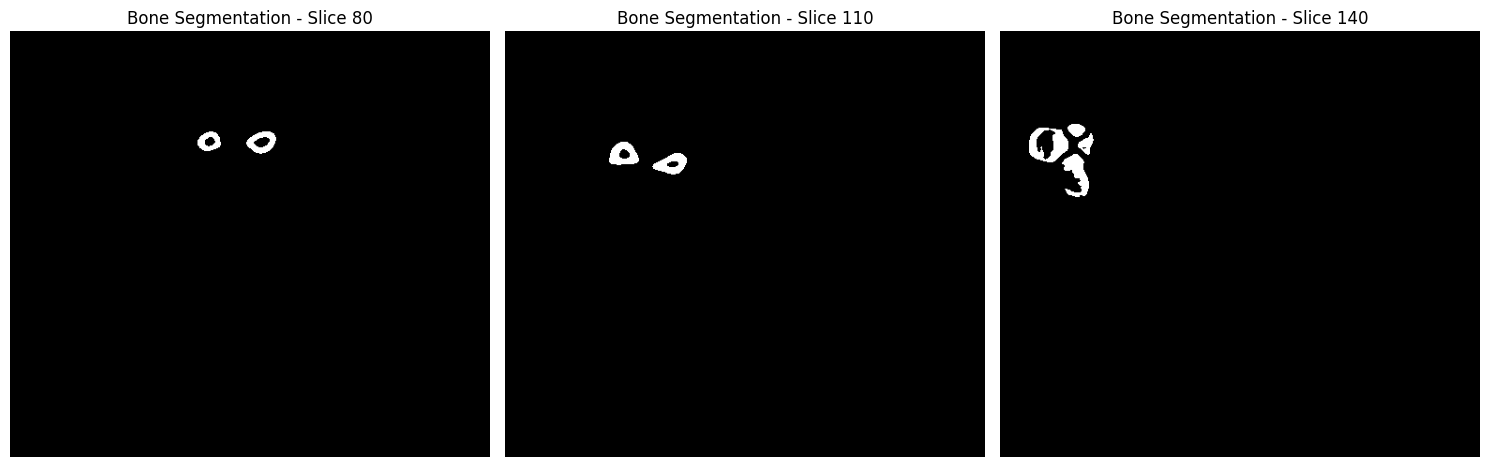

In [30]:
# TODO: YOUR CODE TO SEGMENT BONES
# Bone HU range: 400 to 1900
bone_mask = volume_hu.copy()
bone_mask[bone_mask < 400] = 0
bone_mask[bone_mask > 1900] = 0
bone_mask[bone_mask != 0] = 1

# Show 3 slices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
slices = [80, 110, 140]
for ax, s in zip(axes, slices):
    ax.imshow(bone_mask[s], cmap='gray')
    ax.set_title(f'Bone Segmentation - Slice {s}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Are the segmentations good?

In [ ]:
# TODO: YOUR ANSWER

In [31]:
# TODO: YOUR ANSWER
print("""
The segmentations are reasonably good:

1. Fat Segmentation (HU: -190 to -30):
   - Successfully isolates fatty tissue around the arm
   - The segmentation shows the subcutaneous fat layer around the muscles
   - Some noise may be present at the boundaries

2. Soft Tissue Segmentation (HU: -30 to 150):
   - Effectively captures muscles, tendons, and blood vessels
   - The segmentation clearly shows the muscle groups of the forearm
   - Some partial volume effects at bone/soft tissue boundaries

3. Bone Segmentation (HU: 400 to 1900):
   - Best performing segmentation of the three
   - Clearly isolates cortical bone and bone marrow
   - The radius, ulna, and hand bones are well segmented
   - Clean separation from surrounding soft tissue

Overall the thresholding approach works well for bones since they have
a very distinct HU range. Fat and soft tissue segmentations are decent
but could be improved with more advanced techniques like region growing
or deep learning based segmentation.
""")


The segmentations are reasonably good:

1. Fat Segmentation (HU: -190 to -30):
   - Successfully isolates fatty tissue around the arm
   - The segmentation shows the subcutaneous fat layer around the muscles
   - Some noise may be present at the boundaries

2. Soft Tissue Segmentation (HU: -30 to 150):
   - Effectively captures muscles, tendons, and blood vessels
   - The segmentation clearly shows the muscle groups of the forearm
   - Some partial volume effects at bone/soft tissue boundaries

3. Bone Segmentation (HU: 400 to 1900):
   - Best performing segmentation of the three
   - Clearly isolates cortical bone and bone marrow
   - The radius, ulna, and hand bones are well segmented
   - Clean separation from surrounding soft tissue

Overall the thresholding approach works well for bones since they have 
a very distinct HU range. Fat and soft tissue segmentations are decent 
but could be improved with more advanced techniques like region growing 
or deep learning based segmentatio

In [ ]:
#
# Thank you and Great job!!
#
#                _.---._
#              .'       `.
#              :)       (:
#              \ (@) (@) /
#               \   A   /
#                )     (
#                \"""""/
#                 `._.'
#                  .=.
#          .---._.-.=.-._.---.
#         / ':-(_.-: :-._)-:` \
#        / /' (__.-: :-.__) `\ \
#       / /  (___.-` '-.___)  \ \
#      / /   (___.-'^`-.___)   \ \
#     / /    (___.-'=`-.___)    \ \
#    / /     (____.'=`.____)     \ \
#   / /       (___.'=`.___)       \ \
#  (_.;       `---'.=.`---'       ;._)
#  ;||        __  _.=._  __        ||;
#  ;||       (  `.-.=.-.'  )       ||;
#  ;||       \    `.=.'    /       ||;
#  ;||        \    .=.    /        ||;
#  ;||       .-`.`-._.-'.'-.       ||;
# .:::\      ( ,): O O :(, )      /:::.
# |||| `     / /'`--'--'`\ \     ' ||||
# ''''      / /           \ \      ''''
#          / /             \ \
#         / /               \ \
#        / /                 \ \
#       / /                   \ \
#      / /                     \ \
#     /.'                       `.\
#    (_)'                       `(_)
#     \\.                       .//
#      \\.                     .//
#       \\.                   .//
#        \\.                 .//
#         \\.               .//
#          \\.             .//
#     jgs   \\.           .//
#           ///)         (\\\
#         ,///'           `\\\,
#        ///'               `\\\
#       ""'                   '""